## Charger le split déja crée dans 'clustering_stratifie.ipynb' 

In [3]:

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb


ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

X = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y = pd.read_parquet(DATA_PROCESSED / "Y.parquet")

idx_train = np.load(DATA_PROCESSED / "idx_train.npy")
idx_test  = np.load(DATA_PROCESSED / "idx_test.npy")

X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]

Y_train = Y.iloc[idx_train]
Y_test  = Y.iloc[idx_test]

print(X_train.shape, X_test.shape)



(439976, 110) (109995, 110)


## Créer un validation set
#### On conserve la meme stratification en utilisant 'stratum-final'

In [4]:


labels = pd.read_parquet(
    DATA_PROCESSED / "cluster_labels.parquet"
)

stratum_train = labels.iloc[idx_train]["stratum_final"]

X_train_final, X_val, Y_train_final, Y_val, strat_train, strat_val = train_test_split(
    X_train,
    Y_train,
    stratum_train,
    test_size=0.15,
    random_state=42,
    stratify=stratum_train
)

print("Train :", X_train_final.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)



Train : (373979, 110)
Val   : (65997, 110)
Test  : (109995, 110)


## Baseline naive

In [5]:



TARGET = "out.electricity.total.energy_consumption..kwh"

dummy = DummyRegressor(strategy="median")
dummy.fit(X_train_final, Y_train_final[TARGET])

pred_dummy = dummy.predict(X_test)

print("RMSE :",
      np.sqrt(mean_squared_error(Y_test[TARGET], pred_dummy)))
print("MAE  :",
      mean_absolute_error(Y_test[TARGET], pred_dummy))
print("R²   :",
      r2_score(Y_test[TARGET], pred_dummy))



RMSE : 8810.030773095032
MAE  : 5966.353820112561
R²   : -0.05680623981138044


## Definition du modèle lightgbm 

In [6]:


SEED = 42

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)



## Entrainer LightGBM

In [7]:
model.fit(
    X_train_final,
    Y_train_final[TARGET],
    eval_set=[
        (X_val, Y_val[TARGET])
    ],
    callbacks=[
        lgb.early_stopping(50)
    ]
)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 373979, number of used features: 110
[LightGBM] [Info] Start training from score 11759.399693
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 1.17557e+07


,num_leaves,63
,learning_rate,0.05
,n_estimators,1000
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None


In [8]:

model.fit(
    X_train_final,
    Y_train_final[TARGET],
    eval_set=[
        (X_val, Y_val[TARGET])
    ],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

print("Meilleure itération :", model.best_iteration_)




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 373979, number of used features: 110
[LightGBM] [Info] Start training from score 11759.399693
[100]	valid_0's l2: 1.66645e+07
[200]	valid_0's l2: 1.40569e+07
[300]	valid_0's l2: 1.30128e+07
[400]	valid_0's l2: 1.25517e+07
[500]	valid_0's l2: 1.2281e+07
[600]	valid_0's l2: 1.21118e+07
[700]	valid_0's l2: 1.20062e+07
[800]	valid_0's l2: 1.18942e+07
[900]	valid_0's l2: 1.18134e+07
[1000]	valid_0's l2: 1.17557e+07
Meilleure itération : 1000


In [ ]:
y_pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test[TARGET], y_pred_test))
mae = mean_absolute_error(Y_test[TARGET], y_pred_test)
r2 = r2_score(Y_test[TARGET], y_pred_test)

print(f"Test RMSE : {rmse:.1f} kWh")
print(f"Test MAE  : {mae:.1f} kWh")
print(f"Test R²   : {r2:.4f}")

Test RMSE : 3390.4 kWh
Test MAE  : 1705.6 kWh
Test R²   : 0.8435


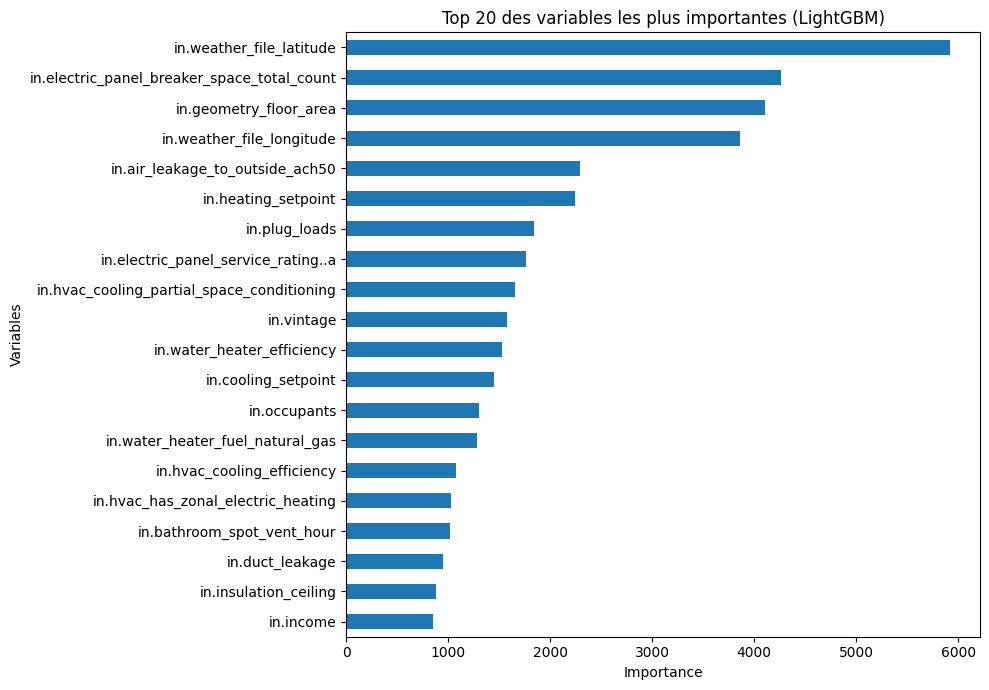


Top 20 variables importantes :
in.weather_file_latitude                       5919
in.electric_panel_breaker_space_total_count    4266
in.geometry_floor_area                         4108
in.weather_file_longitude                      3863
in.air_leakage_to_outside_ach50                2295
in.heating_setpoint                            2245
in.plug_loads                                  1842
in.electric_panel_service_rating..a            1760
in.hvac_cooling_partial_space_conditioning     1651
in.vintage                                     1580
in.water_heater_efficiency                     1531
in.cooling_setpoint                            1450
in.occupants                                   1301
in.water_heater_fuel_natural_gas               1277
in.hvac_cooling_efficiency                     1076
in.hvac_has_zonal_electric_heating             1027
in.bathroom_spot_vent_hour                     1012
in.duct_leakage                                 952
in.insulation_ceiling           

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

top20 = importance.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Variables")
plt.title("Top 20 des variables les plus importantes (LightGBM)")
plt.tight_layout()
plt.show()

print("\nTop 20 variables importantes :")
print(top20)


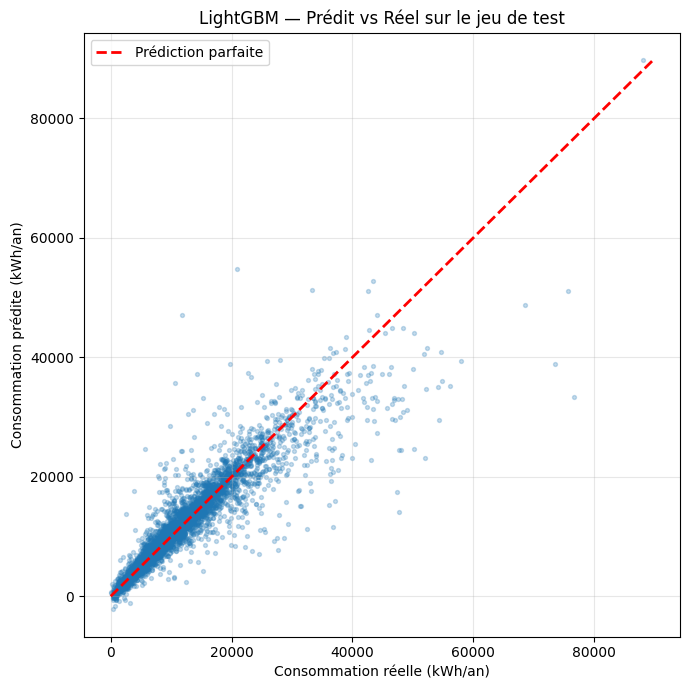

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Échantillon pour éviter un graphique trop chargé
n_points = min(5000, len(Y_test))

sample = np.random.choice(
    len(Y_test),
    size=n_points,
    replace=False
)

y_true_sample = Y_test[TARGET].iloc[sample]
y_pred_sample = y_pred_test[sample]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_true_sample,
    y_pred_sample,
    alpha=0.25,
    s=8
)

# Droite parfaite y = x
max_value = max(y_true_sample.max(), y_pred_sample.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    "r--",
    linewidth=2,
    label="Prédiction parfaite"
)

plt.xlabel("Consommation réelle (kWh/an)")
plt.ylabel("Consommation prédite (kWh/an)")
plt.title("LightGBM — Prédit vs Réel sur le jeu de test")
plt.legend()

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
